In [ ]:
"""
В одни месяцы акции плавно растут, в другие – стоят на месте («боковик»), 
в третьи – обваливаются с бешеной волатильностью. 
Проблема в том, что для банка стратегия управления активами, 
оценки рисков и построения хеджей должна зависеть от текущего режима. 
Например, модель VaR (Value at Risk), настроенная на спокойный рынок, полностью провалится во время паники.

Почему классический подход не работает?
Аналитики часто вручную выделяют кризисы по датам (2008, 2020), 
но между ними есть множество микропереключений: краткосрочные коррекции, 
периоды низкой ликвидности, внезапные скачки волатильности. 
Человек не способен объективно и последовательно сегментировать 10–15 лет ежедневных данных.

Наша задача на семинаре – научить компьютер автоматически находить скрытые режимы рынка.

Без учителя (Unsupervised Learning): Мы не будем давать машине размеченные примеры («это кризис, а это рост»). 
Алгоритм сам обнаружит устойчивые паттерны в доходностях и волатильности.

Смесь гауссиан (GMM): Мы кластеризуем каждый торговый день по набору признаков – например, доходность индекса SPY, 
изменение индекса страха VIX, поведение золота и нефти. 
Модель предположит, что данные порождены тремя разными «генераторами» (режимами), 
каждый из которых имеет свой центр и форму распределения.

Скрытая марковская модель (HMM): В отличие от GMM, HMM учитывает последовательность – режим сегодня сильно зависит от режима вчера. 
Это как цепочка: за спокойным днём с высокой вероятностью идёт спокойный, а за стрессовым – стрессовый. 
HMM строит матрицу переходов между состояниями, что очень ценно для прогнозирования.

Что мы получим на выходе?
Для каждого дня за 15 лет – метку режима (0, 1 или 2). Затем мы интерпретируем эти режимы, например:

Режим «Рост»: доходность SPY положительная, VIX падает, волатильность низкая.

Режим «Стагнация»: доходность около нуля, VIX в боковике.

Режим «Турбулентность» (аналог Contagion): резкие падения SPY, VIX взлетает, корреляции всех активов растут.

Источник данных:
Yahoo Finance API (yfinance). Загружаем дневные цены SPY (ETF на S&P 500 – барометр всего рынка),
VIX (индекс волатильности – «индикатор страха»), GLD (золото – защитный актив), BNO (нефть Brent – сырьевой канал передачи шоков). Период: 10–15 лет, чтобы модель увидела несколько полных экономических циклов.
"""

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

# ==========================
# 1. ЗАГРУЗКА ДАННЫХ
# ==========================
print("Скачиваем данные с Yahoo Finance...")

# Список тикеров:
# SPY - ETF на S&P 500 (основной индекс)
# VIX - индекс волатильности (CBOE)
# GLD - золото
# BNO - нефть Brent (или USO для WTI)
tickers = ['SPY', 'CBOE', 'GLD', 'BNO']

# Загружаем скорректированные цены закрытия за 15 лет (2010–2024)
data = yf.download(tickers, start="2010-01-01", end="2024-12-31")['Close']

[*********************100%***********************]  4 of 4 completed

Скачиваем данные с Yahoo Finance...


### 

In [5]:
!pip3 install hmmlearn

[*********************100%***********************]  4 of 4 completed

Скачиваем данные с Yahoo Finance...
Размер матрицы признаков: (3660, 4)



/var/folders/5d/rj2vhd7s3lgf7m08mvzp24xr0000gn/T/ipykernel_36015/3202975320.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['GMM_Regime'] = gmm_labels
/var/folders/5d/rj2vhd7s3lgf7m08mvzp24xr0000gn/T/ipykernel_36015/3202975320.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['HMM_Regime'] = hmm_states



=== Характеристики режимов (GMM) ===
Режим 0: кол-во дней =  2437 | ср.дох.SPY =  0.126 % | ср.изм.VIX =  0.143 % | волат.SPY = 0.526 %
Режим 1: кол-во дней =  1136 | ср.дох.SPY = -0.080 % | ср.изм.VIX = -0.102 % | волат.SPY = 1.417 %
Режим 2: кол-во дней =    87 | ср.дох.SPY = -0.267 % | ср.изм.VIX = -0.346 % | волат.SPY = 3.733 %

=== Характеристики режимов (HMM) ===
Состояние 0: кол-во дней =   217 | ср.дох.SPY = -0.324 % | ср.изм.VIX = -0.454 % | волат.SPY = 2.762 %
Состояние 1: кол-во дней =  2947 | ср.дох.SPY =  0.114 % | ср.изм.VIX =  0.094 % | волат.SPY = 0.662 %
Состояние 2: кол-во дней =   496 | ср.дох.SPY = -0.149 % | ср.изм.VIX =  0.047 % | волат.SPY = 1.550 %


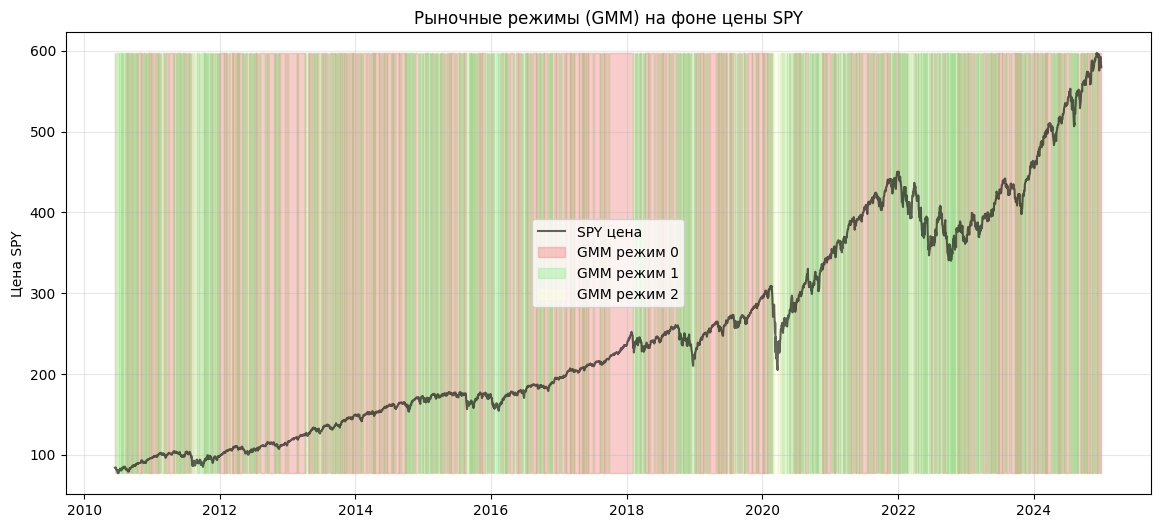

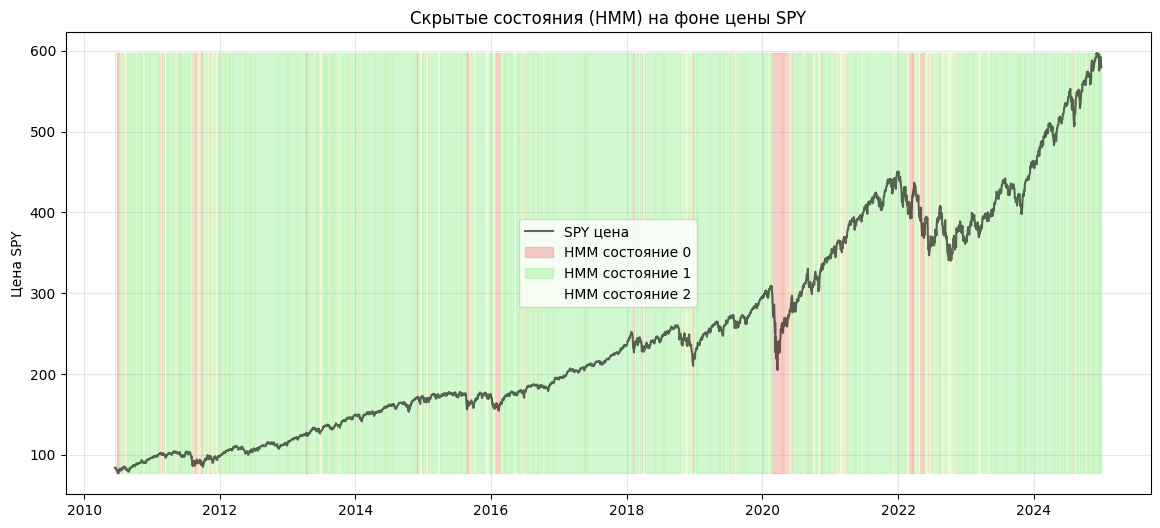

/var/folders/5d/rj2vhd7s3lgf7m08mvzp24xr0000gn/T/ipykernel_36015/3202975320.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X, x='GMM_Regime', y='SPY', ax=axes[0], palette='Set2')
/var/folders/5d/rj2vhd7s3lgf7m08mvzp24xr0000gn/T/ipykernel_36015/3202975320.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X, x='HMM_Regime', y='SPY', ax=axes[1], palette='Set2')


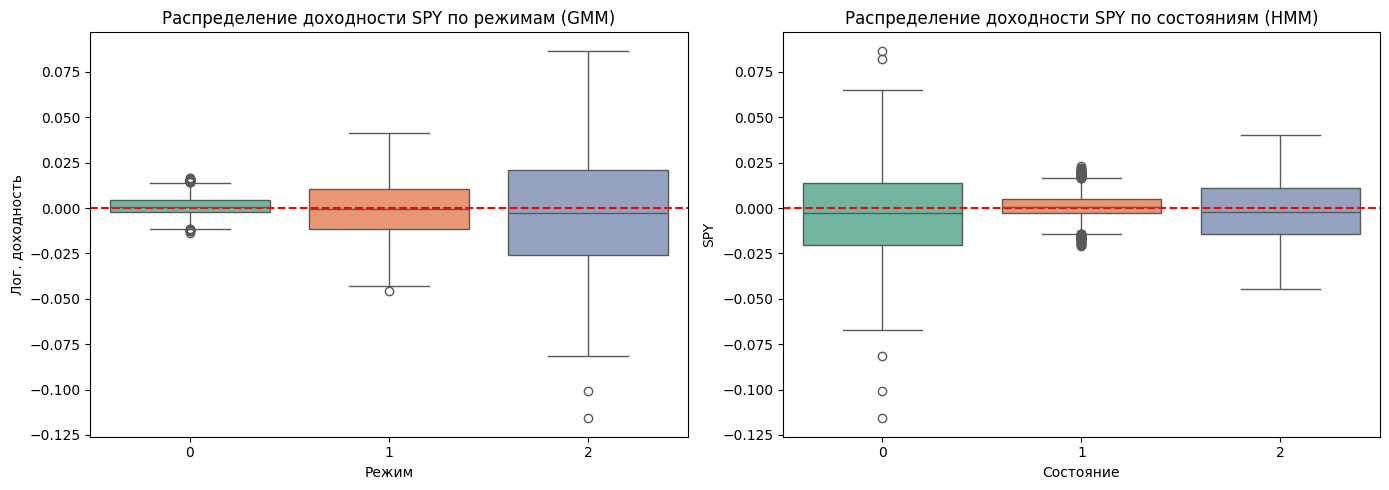

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from hmmlearn import hmm

# ==========================
# 1. ЗАГРУЗКА ДАННЫХ
# ==========================
print("Скачиваем данные с Yahoo Finance...")

# Список тикеров:
# SPY - ETF на S&P 500 (основной индекс)
# VIX - индекс волатильности (CBOE)
# GLD - золото
# BNO - нефть Brent (или USO для WTI)
tickers = ['SPY', 'CBOE', 'GLD', 'BNO']

# Загружаем скорректированные цены закрытия за 15 лет (2010–2024)
data = yf.download(tickers, start="2010-01-01", end="2024-12-31")['Close']

# Убираем мультииндекс, если он есть
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Сохраним отдельно цену SPY для визуализации
spy_price = data['SPY'].copy()

# ==========================
# 2. РАСЧЁТ ПРИЗНАКОВ (features)
# ==========================
# TODO 2.1: Рассчитайте ежедневные логарифмические доходности для всех активов.
returns = np.log(data / data.shift(1))# <ВАШ_КОД: примените np.log и .shift(1) к data, затем удалите первую строку (dropna)>

# TODO 2.2: Сформируйте матрицу признаков X для моделей.
# Базовые признаки:
#   - Доходность SPY (log return)
#   - Изменение VIX (лог. доходность VIX, т.к. VIX — это индекс уровня)
#   - Доходность золота (GLD)
#   - Доходность нефти (BNO)
# Объедините их в DataFrame X.
X = returns.dropna()#pd.DataFrame()

print("Размер матрицы признаков:", X.shape)

# ==========================
# 3. КЛАСТЕРИЗАЦИЯ С ПОМОЩЬЮ GMM (без учителя)
# ==========================
# TODO 3.1: Обучите Gaussian Mixture Model (GMM) с числом компонент = 3.

gmm = GaussianMixture(n_components=3)# <ВАШ_КОД: инициализация модели>

# TODO 3.2: Обучите модель на матрице X (метод .fit())
# <ВАШ_КОД: gmm.fit(...)>
gmm.fit(X)
# TODO 3.3: Предскажите наиболее вероятный кластер (режим) для каждого дня.
# Используйте метод .predict().
gmm_labels = gmm.predict(X)# <ВАШ_КОД: получение меток кластеров (0,1,2)>

# Добавим метки GMM в DataFrame X
X['GMM_Regime'] = gmm_labels

# ==========================
# 4. СКРЫТАЯ МАРКОВСКАЯ МОДЕЛЬ (HMM)
# ==========================
# HMM учитывает последовательность наблюдений (в отличие от GMM)
# TODO 4.1: Создайте модель GaussianHMM с 3 скрытыми состояниями, тип ковариации 'full'.
hmm_model = hmm.GaussianHMM(n_components=3, covariance_type='full')# <ВАШ_КОД: инициализация HMM>

# TODO 4.2: Обучите HMM на признаках X (без колонки с метками).
features_for_hmm = X[['SPY', 'CBOE', 'GLD', 'BNO']].values
hmm_model.fit(features_for_hmm)

# TODO 4.3: Предскажите наиболее вероятную последовательность скрытых состояний.
hmm_states = hmm_model.predict(features_for_hmm)# <ВАШ_КОД: метод .predict() на тех же признаках>

# Сохраним состояния HMM в X
X['HMM_Regime'] = hmm_states

# ==========================
# 5. ИНТЕРПРЕТАЦИЯ РЕЖИМОВ
# ==========================
# Для каждого режима (0,1,2) рассчитаем:
#   - среднюю доходность SPY
#   - среднее изменение VIX
#   - волатильность SPY (std доходности)
print("\n=== Характеристики режимов (GMM) ===")
for regime in range(3):
    subset = X[X['GMM_Regime'] == regime]
    mean_spy = subset['SPY'].mean()
    mean_vix = subset['CBOE'].mean()
    vol_spy = subset['SPY'].std()
    print(f"Режим {regime}: кол-во дней = {len(subset):5d} | "
          f"ср.дох.SPY = {mean_spy*100:6.3f} % | "
          f"ср.изм.VIX = {mean_vix*100:6.3f} % | "
          f"волат.SPY = {vol_spy*100:5.3f} %")

# Аналогично для HMM
print("\n=== Характеристики режимов (HMM) ===")
for state in range(3):
    subset = X[X['HMM_Regime'] == state]
    mean_spy = subset['SPY'].mean()
    mean_vix = subset['CBOE'].mean()
    vol_spy = subset['SPY'].std()
    print(f"Состояние {state}: кол-во дней = {len(subset):5d} | "
          f"ср.дох.SPY = {mean_spy*100:6.3f} % | "
          f"ср.изм.VIX = {mean_vix*100:6.3f} % | "
          f"волат.SPY = {vol_spy*100:5.3f} %")

# TODO 5.1: Переназовите режимы вручную на основе полученных характеристик.
# Например: 0 = "Турбулентность" (низкая доходность, высокая волатильность, рост VIX)
#           1 = "Рост" (положительная доходность, низкая/средняя волатильность, падение VIX)
#           2 = "Стагнация/боковик" (нулевая доходность, низкая волатильность, нейтральный VIX)
# Присвойте осмысленные имена (словарь).

# ==========================
# 6. ВИЗУАЛИЗАЦИЯ
# ==========================
# Синхронизируем индексы: цены SPY и признаки X имеют одинаковую дату после dropna()
common_index = X.index
spy_price_aligned = spy_price.loc[common_index]

# График 1: Цена SPY с цветовой маркировкой режимов GMM
plt.figure(figsize=(14, 6))
plt.plot(spy_price_aligned.index, spy_price_aligned.values, color='black', alpha=0.6, label='SPY цена')
# Раскрашиваем фон в зависимости от режима
colors_gmm = {0: 'lightcoral', 1: 'lightgreen', 2: 'lightyellow'}
for regime, color in colors_gmm.items():
    mask = X['GMM_Regime'] == regime
    plt.fill_between(spy_price_aligned.index, spy_price_aligned.min(), spy_price_aligned.max(),
                     where=mask, color=color, alpha=0.4, label=f'GMM режим {regime}')
plt.title('Рыночные режимы (GMM) на фоне цены SPY')
plt.ylabel('Цена SPY')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# График 2: Аналогично для HMM
plt.figure(figsize=(14, 6))
plt.plot(spy_price_aligned.index, spy_price_aligned.values, color='black', alpha=0.6, label='SPY цена')
colors_hmm = {0: 'lightcoral', 1: 'lightgreen', 2: 'lightyellow'}
for state, color in colors_hmm.items():
    mask = X['HMM_Regime'] == state
    plt.fill_between(spy_price_aligned.index, spy_price_aligned.min(), spy_price_aligned.max(),
                     where=mask, color=color, alpha=0.4, label=f'HMM состояние {state}')
plt.title('Скрытые состояния (HMM) на фоне цены SPY')
plt.ylabel('Цена SPY')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# График 3: Сравнение распределения доходности SPY по режимам (boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# GMM
sns.boxplot(data=X, x='GMM_Regime', y='SPY', ax=axes[0], palette='Set2')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Распределение доходности SPY по режимам (GMM)')
axes[0].set_xlabel('Режим')
axes[0].set_ylabel('Лог. доходность')
# HMM
sns.boxplot(data=X, x='HMM_Regime', y='SPY', ax=axes[1], palette='Set2')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Распределение доходности SPY по состояниям (HMM)')
axes[1].set_xlabel('Состояние')
plt.tight_layout()
plt.show()

# ==========================
# 7. ДИСКУССИЯ (вопросы для группы)
# ==========================
# - Какой метод (GMM или HMM) лучше разделяет режимы? Почему?
# - Совпадают ли режимы, выделенные GMM и HMM? Если нет, в чём разница?
# - Как можно использовать эти режимы для стресс-тестирования портфеля?
# - Какой режим соответствует "эффекту заражения" (кризису)? 
# - Какие дополнительные признаки (макро, ликвидность) могли бы улучшить модель?

# Дополнительное задание (если успеем):
# Построить матрицу переходов между состояниями HMM и обсудить "память" рынка.